In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import os
import astropy as ap
from tqdm import tqdm as tqdm

In [27]:
from urllib.request import urlretrieve
filename = '../solutions/dr7qso.dat'
if not os.path.exists(filename):
   urlretrieve("https://das.sdss.org/va/qsocat/dr7qso.dat", filename)
z = np.loadtxt(filename,skiprows=80, usecols=3)

max = 0.5688479785618046


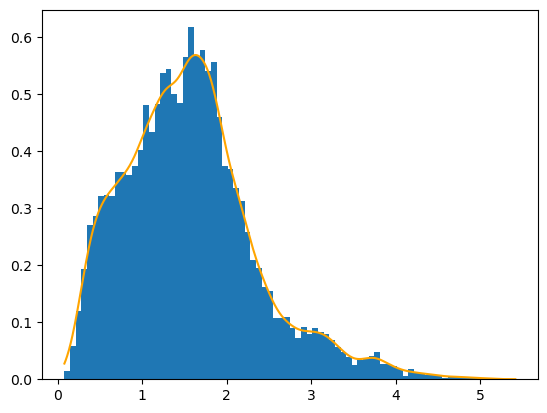

In [88]:
hist = plt.hist(z, bins=80, density=True)
pdf = sp.stats.gaussian_kde(z)
xx = np.linspace(min(z), max(z),1000)
plt.plot(xx, pdf(xx), c='orange')
print('max =',max(pdf(xx)))

# Rejection sampling

In [99]:
mock_rej = []
x = np.random.uniform(min(z), max(z), size=(int(1e4)))
y = np.random.uniform(0, 0.57, size=(int(1e4)))
mock_rej = x[y<pdf(x)]

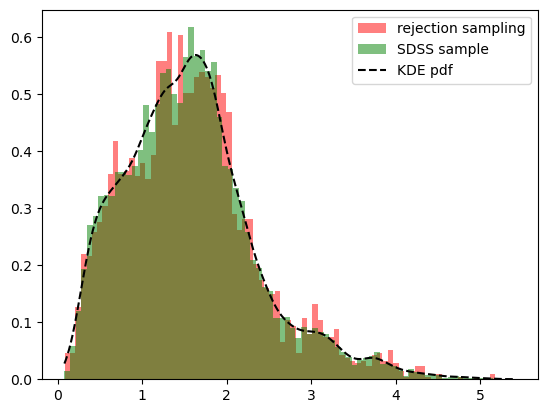

In [100]:
plt.hist(mock_rej, bins=80, density=True, alpha=0.5, color='red', label='rejection sampling')
plt.hist(z, bins=80, density=True, alpha=0.5, color='green', label='SDSS sample')
plt.plot(xx, pdf(xx), c='black', ls='dashed', label='KDE pdf')
plt.legend()
plt.show()

# Inverse Transform sampling

In [101]:
u = np.random.uniform(size=(int(1e4)))
mock_inv = np.quantile(z, u)

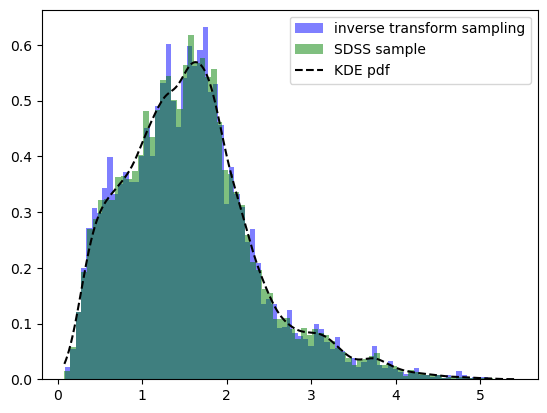

In [102]:
plt.hist(mock_inv, bins=80, density=True, alpha=0.5, color='blue', label='inverse transform sampling')
plt.hist(z, bins=80, density=True, alpha=0.5, color='green', label='SDSS sample')
plt.plot(xx, pdf(xx), c='black', ls='dashed', label='KDE pdf')
plt.legend()
plt.show()

# Comparison

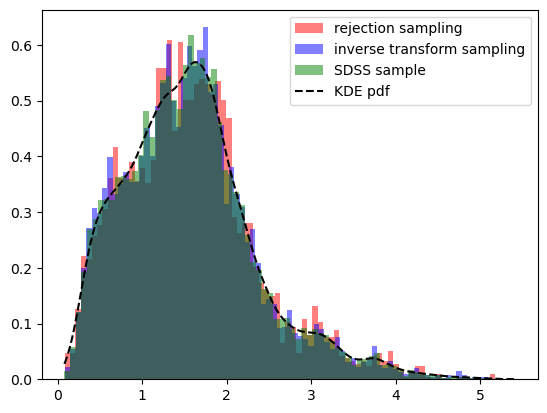

In [103]:
plt.hist(mock_rej, bins=80, density=True, alpha=0.5, color='red', label='rejection sampling')
plt.hist(mock_inv, bins=80, density=True, alpha=0.5, color='blue', label='inverse transform sampling')
plt.hist(z, bins=80, density=True, alpha=0.5, color='green', label='SDSS sample')
plt.plot(xx, pdf(xx), c='black', ls='dashed', label='KDE pdf')
plt.legend()
plt.show()